# **스테이지 6. 하이퍼파라미터 튜닝 & 최종 모델링**

In [ ]:
# drive에 연결합니다.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 현재 데이터가 있는 공간으로 작업 경로를 변경해줍니다.
%cd "/content/drive/MyDrive/AI/Data Set/신용카드_사용자 연체 예측"

Mounted at /content/drive
/content/drive/MyDrive/ML_Data/Dacon/데이크루6기/신용카드/open


스테이지 5에서는 더 좋은 예측 결과를 만들기 위해 <font color=blue>**Feature Engineering**</font>을 진행해주었습니다.<br>
이번 스테이지에서는 여러 모델들을 비교하고 <font color=red>**하이퍼파라미터 튜닝**</font>으로 최적의 모델을 찾아보겠습니다!

이번에 저희가 다뤄볼 모델은 아래의 4가지입니다!<br>

* 의사결정나무 (Decision Tree)

* 랜덤포레스트 (Random Forest)

* XGBoost

* LightGBM

## **앙상블 모델 (Ensemble Model)**

이번에 저희가 학습할 모델 중 의사결정나무를 제외한 나머지 세 개의 모델은 모두 **앙상블 모델**입니다.

앙상블 기법은 여러 개의 기본 모델을 결합하여 <font color=red>**더 강력하고 정확한 모델**</font>을 만드는 머신러닝 기법입니다.<br>
앙상블은 단일 모델보다 더 좋은 예측 성능을 얻을 수 있고, 과적합을 줄이며 안정적인 결과를 얻을 수 있는 장점이 있습니다!

앙상블 기법은 여러 가지가 있습니다.<br>
그 중 주로 사용하는 앙상블 기법의 종류에는 **보팅(Voting) / 배깅(Bagging) / 부스팅(Boosting)** 3가지가 있습니다.<br>

### **보팅(Voting)**
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FbnoYi8%2FbtrHowxaUjI%2FKfqn6jrFrUaUzc2NjN1HV1%2Fimg.png">

 **보팅(Voting)**은 그 단어에서 알 수 있듯이, 서로 다른 알고리즘을 가진 분류기 중 투표를 통하여<br>
최종 예측 결과를 결정하는 방식입니다.<br>
여러 다른 알고리즘의 예측을 평균하거나 다수결 원칙에 따라 최종 예측을 결정합니다.<br>

보팅은 기본 모델로 여러 개의 알고리즘을 사용할 수 있습니다!<br>
사용되는 대표적인 알고리즘으로는 의사결정나무, KNN(K-Nearest Neighbors), 선형회귀, SVM 등이 있습니다.

보팅은 최종 결과 선정 방식에 따라 **하드 보팅(Hard Voting)**, **소프트 보팅(Soft voting)**의 두 가지로 나눌 수 있습니다.

* 하드 보팅: 예측 결과를 다수결로 결정합니다.

* 소프트 보팅: 예측 확률을 평균하여 최종 예측을 결정합니다.

### **배깅(Bagging, Bootstrap aggregating)**
<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FcQO96B%2FbtrIaO4bLKl%2FpzQEFh7WOfpzZKhKrutZD0%2Fimg.png">

**배깅(Bagging)**은 bootstrap aggregating 의 줄임말로 부트스트랩(bootstrap) 모델을<br>
여러 번 독립적으로 학습시켜 각 모델의 예측을 평균하여 최종 예측을 만드는 방식입니다.<br>

이 때 부트스트랩(bootstrap) 모델란 원시 데이터(raw)로 부터 복원 임의 추출한 크기가<br>
동일한 여러 개의 표본 자료를 말합니다!<br>
보팅과는 다르게 모두 같은 알고리즘 모델을 사용합니다.<br>

대표적으로 **랜덤포레스트(Random Forest)** 알고리즘이 있습니다!

### **부스팅(Boosting)**
<img src="https://miro.medium.com/v2/resize:fit:850/1*DwvwMlOcT1T9hZwIJvMfng.png">

#  부스팅(Boosting)은 가중치를 활용하여 약한 분류기를 강한 분류기로 만드는 방법입니다.<br>

배깅은 여러 개의 모델이 서로 **독립적으로** 결과를 예측한 후, 그 결과 값을 집계해<br>
최종적으로 결과 값을 예측하는 방식인 것에 비해,<br>
처음 모델이 예측을 하면 그 예측 결과에 따라 데이터에 가중치를 부여하고, 부여된 가중치로 다시 재학습을 시킵니다.<br>
그래서 점차 분류기의 규칙과 성능을 **반복학습**을 통해 강화시켜나가는 방식입니다.

<img src="https://blog.kakaocdn.net/dn/blKp9s/btryOxDxV4h/G0ESnPdrd5YBprzWjishs0/img.png">

위의 그림이 바로 배깅과 부스팅의 차이점을 보여주는 그림입니다!<br>
배깅은 병렬로 학습하는 반면, 부스팅은 순차학습입니다.<br>
부스팅은 배깅에 비해 error가 더 적어서 성능이 좋다는 장점이 있지만, 연속적인<br>
모델 학습을 하기 때문에 속도가 느리고, 오버 피팅이 될 가능성이 높다는 단점이 있습니다.<br>
각 모델의 장단점을 보고, 상황에 맞는 모델을 선택하는 것이 좋습니다.<br>

## **Step 1. Modeling**

### **1. 의사결정나무**
<img src="http://i.imgur.com/ZKDnzOB.png" width=800>

In [ ]:
# 데이터 분석에 필요한 라이브러리들을 불러옵니다

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Feature Engineering이 끝난 데이터를 불러옵니다

train = pd.read_csv("train_processed.csv")
test = pd.read_csv("test_processed.csv")
submission = pd.read_csv("sample_submission.csv")

In [ ]:
# target의 분포를 살펴봅니다
print(train['credit'].value_counts())

2.0    16968
1.0     6267
0.0     3222
Name: credit, dtype: int64


In [ ]:
X = train.drop(columns='credit')
y = train['credit']

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, stratify=y,
                                                      test_size= 0.2, random_state=42)

#사이킷런의 DecisionTreeClassifier로 모델 학습
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**average:  다중 클래스 분류에서 사용되는 평균 방법을 지정하는 매개변수입니다.**



**< 주요 average 옵션 >**

None: 클래스별로 평가 지표를 계산하고 개별 클래스마다 값을 반환합니다. 이 경우 클래스마다 리콜, 정밀도, F1 스코어 등을 계산한 값을 반환합니다.

'micro': 모든 클래스의 TP, FP, FN을 모두 더하여 전체 데이터에 대한 평가 지표를 계산합니다. 전체 데이터에 대한 하나의 평가 지표 값을 얻을 수 있습니다.

'macro': 각 클래스마다 평가 지표를 계산한 뒤 이들 값을 평균하여 전체 평가 지표 값을 계산합니다. 클래스의 개수에 상관없이 각 클래스의 영향력을 동일하게 취급합니다.

'weighted': 각 클래스마다 평가 지표를 계산한 뒤, 클래스의 샘플 수를 고려하여 가중 평균을 계산하여 전체 평가 지표 값을 계산합니다. 클래스별 샘플 수가 다른 경우 유용합니다.

'samples': 다중 레이블 분류에서 사용되며, 각 샘플에 대해 평가 지표를 계산한 뒤 이들 값을 평균하여 전체 평가 지표 값을 계산합니다.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, log_loss

pred_1 = dt.predict(X_valid)
valid_cm_1 = confusion_matrix(y_valid, pred_1)
valid_acc_1 = accuracy_score(y_valid, pred_1)
valid_recall_1 = recall_score(y_valid, pred_1, average="weighted")
valid_precision_1 = precision_score(y_valid, pred_1, average="weighted")
valid_f1_1 = f1_score(y_valid, pred_1, average="weighted")

print("Confusion Matrix(혼동행렬): \n",valid_cm_1)
print('\n')
print("Accuracy(정확도): ", round(valid_acc_1*100, 2))
print("Recall(재현율): ", round(valid_recall_1*100, 2))
print("Precision(정밀도): ", round(valid_precision_1*100, 2))
print("F1 Score(정밀도, 리콜의 조화평균): ", round(valid_f1_1, 4))

Confusion Matrix(혼동행렬): 
 [[ 323  141  180]
 [ 122  851  281]
 [ 203  310 2881]]


Accuracy(정확도):  76.63
Recall(재현율):  76.63
Precision(정밀도):  76.84
F1 Score(정밀도, 리콜의 조화평균):  0.7672


In [ ]:
from sklearn.metrics import classification_report

# y_valid는 실제 레이블을, pred_1은 모델의 예측 결과
report = classification_report(y_valid, pred_1)
print(report)

              precision    recall  f1-score   support

         0.0       0.50      0.50      0.50       644
         1.0       0.65      0.68      0.67      1254
         2.0       0.86      0.85      0.86      3394

    accuracy                           0.77      5292
   macro avg       0.67      0.68      0.67      5292
weighted avg       0.77      0.77      0.77      5292



In [ ]:
feature_importances = pd.Series(dt.feature_importances_,index=X_valid.columns).sort_values(ascending=False)
feature_importance = feature_importances.head(20)
print(feature_importance)

begin_month            0.201469
DAYS_EMPLOYED          0.125028
income_total           0.117220
DAYS_BIRTH             0.112723
before_employed        0.109601
duplicated_num         0.063891
occyp_type             0.058403
family_type            0.026662
edu_type               0.024559
family_size            0.022939
income_type            0.021437
phone                  0.019315
house_type             0.017584
car                    0.015802
gender                 0.014908
child_num              0.013827
reality                0.012043
work_phone             0.011346
email                  0.011243
child_num_over_five    0.000000
dtype: float64


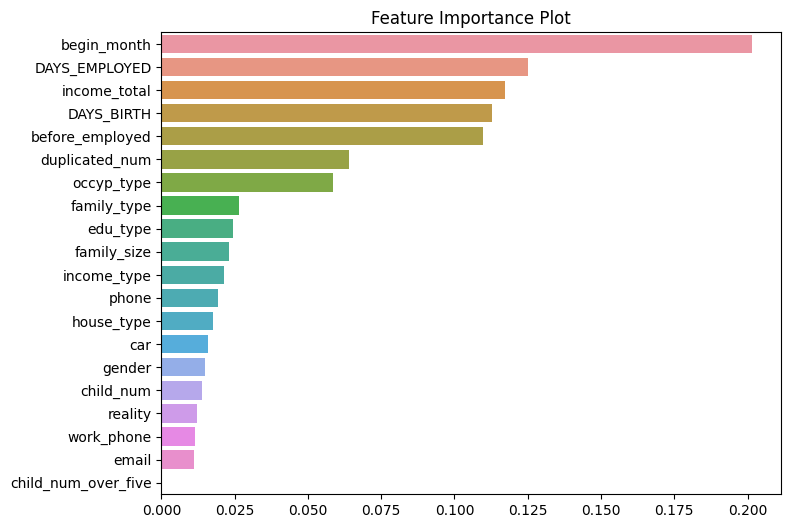

In [ ]:
%matplotlib inline

plt.figure(figsize=(8,6))
plt.title('Feature Importance Plot')
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.show()


In [ ]:
prob_1 = dt.predict_proba(X_valid)

log_loss_1 = log_loss(y_valid, prob_1)
print("Log loss(로그 손실): ", round(log_loss_1, 4))

Log loss(로그 손실):  8.3661


### **2. 랜덤 포레스트(Random Forest)**

<font color=green>**랜덤 포레스트(Random Forest)**</font>는 머신 러닝에서 사용되는 강력한 앙상블(Ensemble) 학습 알고리즘 중 하나입니다.<br>
랜덤 포레스트는 여러 개의 의사결정 트리(Decision Tree)를 생성하고 이들을 조합하여 예측을 수행합니다.<br>
랜덤 포레스트는 배깅(Bagging) 알고리즘을 사용하는 대표적인 모델입니다.


💡 랜덤 포레스트의 주요 특징은 다음과 같습니다.<br>

**과적합 줄임** : 부트스트랩 샘플링과 랜덤 특성 선택을 통해 모델의 과적합(Overfitting)을 줄이는 효과를 가져옵니다.<br>
**앙상블 효과**: 여러 개의 의사결정 트리를 조합하여 강력하고 안정적인 예측을 제공합니다.<br>
**특성 중요도 평가**: 각 트리에서 변수의 중요도를 평가하여 특성의 영향력을 평가할 수 있습니다.<br>
**다양한 데이터 타입 처리**: 범주형 변수와 연속형 변수를 함께 다룰 수 있습니다.<br>

랜덤 포레스트는 분류 및 회귀 문제에 널리 사용되며, 다양한 데이터에 대해 좋은 예측 성능을 보여주는 알고리즘 중 하나입니다.

**< 주요 파라미터 >** <br>

<div class="text_cell_render border-box-sizing rendered_html">
<table>
<thead><tr>
<th style="text-align:center">파라미터 명</th>
<th style="text-align:left">설명</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:center"><strong>n_estimators</strong></td>
<td style="text-align:left">- 결정트리의 갯수를 지정<br> - Default = 10<br>- 무작정 트리 갯수를 늘리면 성능 좋아지는 것 대비 시간이 걸릴 수 있음</td>
</tr>
<tr>
<td style="text-align:center"><strong>min_samples_split</strong></td>
<td style="text-align:left">- 노드를 분할하기 위한 최소한의 샘플 데이터수 <br> → 과적합을 제어하는데 사용<br> - Default = 2 → 작게 설정할 수록 분할 노드가 많아져 과적합 가능성 증가</td>
</tr>
<tr>
<td style="text-align:center"><strong>min_samples_leaf</strong></td>
<td style="text-align:left">- 리프노드가 되기 위해 필요한 최소한의 샘플 데이터수<br>- min_samples_split과 함께 과적합 제어 용도<br>- 불균형 데이터의 경우 특정 클래스의 데이터가 극도로 작을 수 있으므로 작게 설정 필요</td>
</tr>
<tr>
<td style="text-align:center"><strong>max_features</strong></td>
<td style="text-align:left">- 최적의 분할을 위해 고려할 최대 feature 개수<br>- Default = 'auto' (결정트리에서는 default가 none이었음)<br>- int형으로 지정 →피처 갯수 / float형으로 지정 →비중<br>- sqrt 또는 auto : 전체 피처 중 √(피처개수) 만큼 선정<br>- log : 전체 피처 중 log2(전체 피처 개수) 만큼 선정</td>
</tr>
<tr>
<td style="text-align:center"><strong>max_depth</strong></td>
<td style="text-align:left">- 트리의 최대 깊이<br>- default = None<br> → 완벽하게 클래스 값이 결정될 때 까지 분할<br>또는 데이터 개수가 min_samples_split보다 작아질 때까지 분할<br>- 깊이가 깊어지면 과적합될 수 있으므로 적절히 제어 필요</td>
</tr>
<tr>
<td style="text-align:center"><strong>max_leaf_nodes</strong></td>
<td style="text-align:left">리프노드의 최대 개수</td>
</tr>
</tbody>
</table>

</div>

주요 파라미터를 간단하게 알아보았습니다.<br>
그럼 이제 코드 실습을 통해서 모델 생성 부터 학습, 예측결과까지 해보면서
실제 성능을 보도록 하겠습니다!

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

# 모델 학습 및 예측
rf.fit(X_train, y_train)
pred_2 = rf.predict(X_valid)

# 정확도 평가
accuracy = accuracy_score(y_valid, pred_2)
print(f'RandomForestClassifier 정확도: {accuracy:.4f}')

# 오차 행렬
cm2 = confusion_matrix(y_valid, pred_2)
print(cm2)

RandomForestClassifier 정확도: 0.8154
[[ 272   95  277]
 [  29  817  408]
 [  51  117 3226]]


In [ ]:
pred_2 = rf.predict(X_valid)
valid_cm_2 = confusion_matrix(y_valid,pred_2)
valid_acc_2 = accuracy_score(y_valid,pred_2)
valid_recall_2 = recall_score(y_valid,pred_2, average='weighted')
valid_precision_2 = precision_score(y_valid,pred_1, average='weighted')
valid_f1_2 = f1_score(y_valid,pred_2, average='weighted')

print("Confusion Matrix(혼동행렬): \n",valid_cm_2)
print('\n')
print("Accuracy(정확도): ", round(valid_acc_2*100, 2))
print("Recall(재현율): ", round(valid_recall_2*100, 2))
print("Precision(정밀도): ", round(valid_precision_2*100, 2))
print("F1 Score(정밀도,리콜의 조화평균): ", round(valid_f1_2, 4))

Confusion Matrix(혼동행렬): 
 [[ 272   95  277]
 [  29  817  408]
 [  51  117 3226]]


Accuracy(정확도):  81.54
Recall(재현율):  81.54
Precision(정밀도):  76.84
F1 Score(정밀도,리콜의 조화평균):  0.8025


In [ ]:
# 변수 중요도 계산

importances_values = pd.Series(rf.feature_importances_, index=X_valid.columns).sort_values(ascending=False)
fr_top20 = importances_values.head(20)
fr_top20

begin_month            0.207786
DAYS_BIRTH             0.116020
before_employed        0.115361
DAYS_EMPLOYED          0.096652
duplicated_num         0.095870
income_total           0.093134
occyp_type             0.055866
family_type            0.026590
family_size            0.022647
edu_type               0.021673
income_type            0.021251
phone                  0.018305
car                    0.017949
reality                0.017703
child_num              0.017245
gender                 0.016849
house_type             0.015079
work_phone             0.014286
email                  0.009712
child_num_over_five    0.000025
dtype: float64

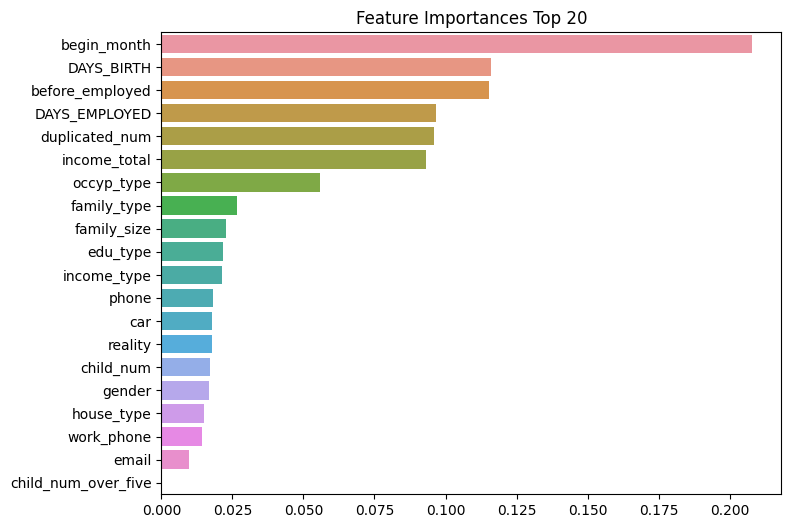

In [ ]:
# 변수 중요도 시각화

plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 20')
sns.barplot(x=fr_top20, y=fr_top20.index)
plt.show()

In [ ]:
y_prob = rf.predict_proba(X_valid)
log_loss_2 = log_loss(y_valid, y_prob)
print("Log Loss: ", round(log_loss_2, 4))

Log Loss:  0.4966


### **3. XGBoost**

<font color=green>**XGBoost(Extreme Gradient Boosting)**</font>은 그래디언트 부스팅(Gradient Boosting) 알고리즘을<br>
분산환경에서도 실행할 수 있도록 구현해놓은 머신러닝 라이브러리입니다.<br>

그래디언트 부스팅은 Gradient와 Boosting을 합친 단어로,<br>
기울기를 줄여가며 결과적으로 잔차를 줄여나가는 학습 방식을 이야기합니다.<br>

약한 예측 모델(Weak Learner)들을 조합하여 강력한 예측 모델을 만드는 XGBoost는 이를 발전시킨 알고리즘입니다!

우선 XGBoost 모델을 사용하기 위해서는 패키지를 설치해주어야 합니다!

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

# 모델 학습 및 예측
xgb.fit(X_train, y_train)
pred_3 = xgb.predict(X_valid)

# 정확도 평가
accuracy = accuracy_score(y_valid, pred_3)
print(f'XGBoost 정확도: {accuracy:.4f}')

# 오차 행렬
cm3 = confusion_matrix(y_valid, pred_3)
print(cm3)

XGBoost 정확도: 0.7232
[[  90   79  475]
 [  18  444  792]
 [  35   66 3293]]


In [ ]:
pred_3 = xgb.predict(X_valid)
valid_cm_3 = confusion_matrix(y_valid, pred_3)
valid_acc_3 = accuracy_score(y_valid, pred_3)
valid_recall_3 = recall_score(y_valid, pred_3, average='weighted')
valid_precision_3 = precision_score(y_valid, pred_3, average='weighted')
valid_f1_3 = f1_score(y_valid, pred_3, average='weighted')

print("Confusion Matrix(혼동행렬): \n",valid_cm_3)
print("\n")
print("Accuracy(정확도): ", round(valid_acc_3*100, 2))
print("Recall(재현율): ", round(valid_recall_3*100, 2))
print("Precision(정밀도): ", round(valid_precision_3*100, 2))
print("F1 Score(정밀도,재현율의 조화평균): ", round(valid_f1_3, 4))

Confusion Matrix(혼동행렬): 
 [[  90   79  475]
 [  18  444  792]
 [  35   66 3293]]


Accuracy(정확도):  72.32
Recall(재현율):  72.32
Precision(정밀도):  71.84
F1 Score(정밀도,재현율의 조화평균):  0.673


In [ ]:
xgb_importances_values = xgb.feature_importances_
xgb_importances_values

array([0.03532011, 0.04608109, 0.04276669, 0.04204773, 0.04579745,
       0.04139627, 0.04715922, 0.05050854, 0.05041166, 0.05169708,
       0.05418397, 0.05758152, 0.05462679, 0.04661645, 0.04812541,
       0.0386807 , 0.12717871, 0.        , 0.06772235, 0.05209821,
       0.        ], dtype=float32)

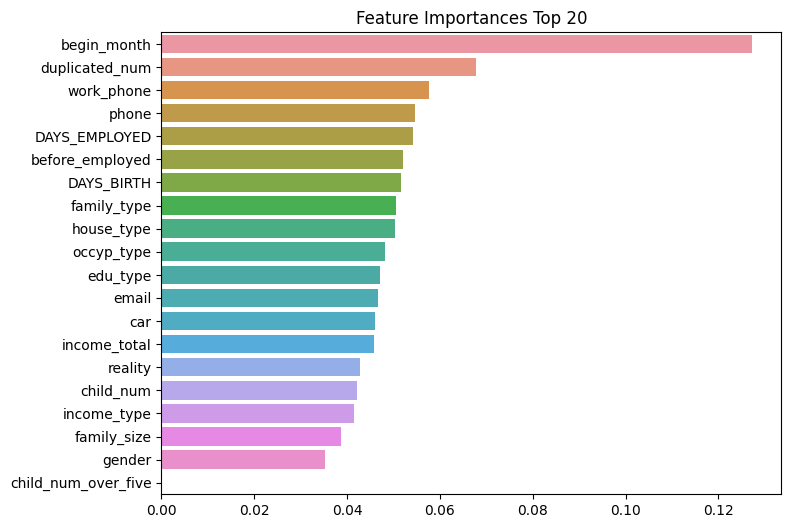

In [ ]:
# 변수 중요도 시각화

xgb_importances = pd.Series(xgb_importances_values, index=X_valid.columns).sort_values(ascending=False)
xgb_top20 = xgb_importances.head(20)

plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 20')
sns.barplot(x=xgb_top20, y=xgb_top20.index)
plt.show()


In [ ]:
# log_loss를 계산합니다

y_prob = xgb.predict_proba(X_valid)
log_loss_3 = log_loss(y_valid, y_prob)
print("Log Loss: ", round(log_loss_3, 4))

Log Loss:  0.6441


### **4. LightGBM**

LightGBM에서 gbm 은 Gradient Boosting Model 로 , Tree를 기반으로 하는 학습 알고리즘입니다.<br>
이 모델 또한 가중치를 더하면서 진행하는 방법이기 때문에 XGBoost와 비슷합니다.

LightGBM의 차이점은 다른 알고리즘들과 다르게 Leaf-wise 분할을 한다는 점입니다!<br>
Leaf-wise 분할은 Level-wise 분할과 다르게 수직적으로 뻗어나간다는 차이점이 있습니다.<br>


트리의 균형을 맞추지 않고 최대 손실 값을 갖는 리프 노드를 지속적으로 분할하면서 깊고 비대칭적인 트리를 생성하고,<br>
기존의 트리 기준 분할 방식에 비해 예측 오류 손실을 최소화하여 예측 성능을 높일 수 있습니다.<br>
다만, 데이터가 적을 경우 과적합의 위험이 있습니다.

**< LightGBM 파라미터 >**

<table style="border-collapse: collapse; width: 100%;" border="1" data-ke-align="alignLeft" data-ke-style="style12">
<tbody>
<tr>
<td style="width: 25.6589%; text-align: center;">파라미터</td>
<td style="width: 14.7286%; text-align: center;">default</td>
<td style="width: 59.6124%; text-align: center;">설명</td>
</tr>
<tr>
<td style="width: 25.6589%;">num_iterations</td>
<td style="width: 14.7286%; text-align: center;">100</td>
<td style="width: 59.6124%;">반복 수행하려는 트리의 개수 (너무 크면 오버피팅 발생)</td>
</tr>
<tr>
<td style="width: 25.6589%;">objective</td>
<td style="width: 14.7286%; text-align: center;">regression</td>
<td style="width: 59.6124%;">수치예측이면 regression, 이진분류이면 binary</td>
</tr>
<tr>
<td style="width: 25.6589%;">learning_rate</td>
<td style="width: 14.7286%; text-align: center;">0.1</td>
<td style="width: 59.6124%;">부스팅 스탭 반복할 때 학습률, 0~1 사이의 값</td>
</tr>
<tr>
<td style="width: 25.6589%;">max_depth</td>
<td style="width: 14.7286%; text-align: center;">1</td>
<td style="width: 59.6124%;">트리의 깊이</td>
</tr>
<tr>
<td style="width: 25.6589%;">min_data_in_leaf</td>
<td style="width: 14.7286%; text-align: center;">20</td>
<td style="width: 59.6124%;">한 리프의 최소 데이터 수<br>(decision tree의 min_sample_leaf와 동일, 오버피팅 제어)</td>
</tr>
<tr>
<td style="width: 25.6589%;">num_leaves</td>
<td style="width: 14.7286%; text-align: center;">31</td>
<td style="width: 59.6124%;">하나의 트리가 가질 수 있는 최대 리프 개수</td>
</tr>
<tr>
<td style="width: 25.6589%;">boosting</td>
<td style="width: 14.7286%; text-align: center;">gbdt</td>
<td style="width: 59.6124%;">부스팅 방법 (gbdt: Gradient Boosting DecisionTree / rf: RandomForest)</td>
</tr>
<tr>
<td style="width: 25.6589%;">bagging_fraction</td>
<td style="width: 14.7286%; text-align: center;">1.0</td>
<td style="width: 59.6124%;">데이터 샘플링 비율, 오버피팅 제어</td>
</tr>
<tr>
<td style="width: 25.6589%;">feature_fraction</td>
<td style="width: 14.7286%; text-align: center;">1.0</td>
<td style="width: 59.6124%;">개별 트리 학습 시 무작위로 선택하는 feature의 비율</td>
</tr>
<tr>
<td style="width: 25.6589%;">lambda_l1</td>
<td style="width: 14.7286%; text-align: center;">0.0</td>
<td style="width: 59.6124%;">L1 regulation 제어</td>
</tr>
<tr>
<td style="width: 25.6589%;">lambda_l2</td>
<td style="width: 14.7286%; text-align: center;">0.0</td>
<td style="width: 59.6124%;">L2 regulation 제어</td>
</tr>
<tr>
<td style="width: 25.6589%;">metric</td>
<td style="width: 14.7286%; text-align: center;">""</td>
<td style="width: 59.6124%;">성능평가를 어떤 것으로 할 것인지 (auc, l1, l2 등)</td>
</tr>
</tbody>
</table>

num_leaves: 클수록 정확도는 높아지지만 오버피팅 발생 가능

min_data_in_leaf: 클수록 오버피팅 방지

max_depth: 위 두개 파라미터와 결합하여 오버피팅 방지

objective: 사용하는 데이터셋의 타겟팅 값의 형태에 따라 조정 필요

metric: 성능 평가를 어떤 것으로 할 것인지 조정 필요

LightGBM도 XGBoost와 마찬가지로 패키지를 설치해주어야 합니다.

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)

# 모델 학습 및 예측
lgbm.fit(X_train, y_train)
pred_4 = lgbm.predict(X_valid)

# 정확도 평가
accuracy = accuracy_score(y_valid, pred_4)
print(f'LGBM 정확도: {accuracy:.4f}')

# 오차 행렬
cm4 = confusion_matrix(y_valid, pred_4)
print(cm4)

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1094
[LightGBM] [Info] Number of data points in the train set: 21165, number of used features: 19
[LightGBM] [Info] Start training from score -2.105335
[LightGBM] [Info] Start training from score -1.440314
[LightGBM] [Info] Start training from score -0.444193
LGBM 정확도: 0.7203
[[  63   76  505]
 [   3  383  868]
 [   5   23 3366]]


In [ ]:
pred_4 = lgbm.predict(X_valid)
valid_cm_4 = confusion_matrix(y_valid, pred_4)
valid_acc_4 = accuracy_score(y_valid, pred_4)
valid_recall_4 = recall_score(y_valid, pred_4, average='weighted')
valid_precision_4 = precision_score(y_valid, pred_4, average='weighted')
valid_f1_4 = f1_score(y_valid, pred_4, average='weighted')

print("Confusion Matrix(혼동행렬): \n", valid_cm_4)
print('\n')
print("Accuracy(정확도): ", round(valid_acc_4*100, 2))
print("Recall(재현율): ", round(valid_recall_4*100, 2))
print("Precision(정밀도): ", round(valid_precision_4*100, 2))
print("F1 Score(정밀도, 리콜의 조화평균): ", round(valid_f1_4, 4))

Confusion Matrix(혼동행렬): 
 [[  63   76  505]
 [   3  383  868]
 [   5   23 3366]]


Accuracy(정확도):  72.03
Recall(재현율):  72.03
Precision(정밀도):  75.18
F1 Score(정밀도, 리콜의 조화평균):  0.6569


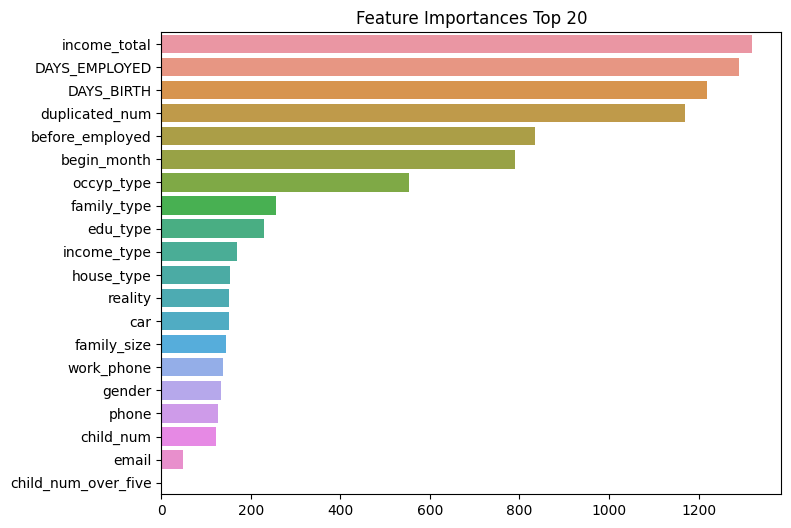

In [ ]:
light_importaces_values = lgbm.feature_importances_
light_importaces = pd.Series(light_importaces_values, index=X_valid.columns).sort_values(ascending=False)
light_top20 = light_importaces.head(20)

plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 20')
sns.barplot(x=light_top20, y=light_top20.index)
plt.show()


In [ ]:
# log_loss를 계산합니다

y_prob = lgbm.predict_proba(X_valid)
log_loss_4 = log_loss(y_valid, y_prob)
print("Log Loss: ", round(log_loss_4, 4))

Log Loss:  0.6669


### **5. 모델 성능 비교하기**

In [ ]:
# f1_score를 비교합니다

print(f'의사결정나무\t{round(valid_f1_1, 4)}')
print(f'랜덤포레스트\t{round(valid_f1_2, 4)}')
print(f'XGBoost\t\t{round(valid_f1_3, 4)}')
print(f'LightGBM\t{round(valid_f1_4, 4)}')

의사결정나무	0.7672
랜덤포레스트	0.8025
XGBoost		0.673
LightGBM	0.6569


In [ ]:
# log_loss를 비교합니다

print(f'의사결정나무\t{round(log_loss_1, 4)}')
print(f'랜덤포레스트\t{round(log_loss_2, 4)}')
print(f'XGBoost\t\t{round(log_loss_3, 4)}')
print(f'LightGBM\t{round(log_loss_4, 4)}')

의사결정나무	8.3661
랜덤포레스트	0.4966
XGBoost		0.6441
LightGBM	0.6669


## **Step 2. Hyperparameter Tuning**

**하이퍼파라미터 튜닝**이란 모델을 최적화하기 위해 하이퍼파라미터를 조정하는 과정을 말합니다!

하이퍼파라미터 튜닝을 왜 해야할까요?

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_ensemble_oob_001.png">

위의 그래프는 모두 랜덤 포레스트이지만, `max_features` 하이퍼파라미터를 다르게 설정하여<br>
에러율이 차이가 많이 나는 것을 볼 수 있습니다.<br>

모두 같은 모델을 사용했지만 하이퍼파라미터 값의 변경에 따라 예측에 큰 영향을 미치죠!<br>

일반적으로 하이퍼파라미터 튜닝을 하는 방법은 **Grid Search**와 **Random Search**가 있습니다.<br>

- Grid Search : 그리드 서치는 각 매개변수의 후보를 정하고 이들 **조합**을 모두 계산하는 방법입니다.<br>
탐색할 매개변수의 후보를 파악하기는 쉽지만, 조합에는 어디까지나 한계가 있기<br> 때문에 후보 수를 많이 지정하기는 어렵습니다.<br>

- Random Search : 랜덤 서치는 각 매개변수의 후보를 정하고 매개변수별로 **랜덤하게 선택**한 조합을 만듭니다.<br>
그리고 계산 과정에서 설정한 횟수만큼 반복하는 방법입니다.<br>
매개변수의 후보로 분포를 지정할 수 있고, 어떤 매개변수에 대해 일정 범위의 균등분포에서 선택할 수 있습니다.<br>

⚠️ **하이퍼파라미터 튜닝은 많은 모델을 테스트해보기 때문에 시간이 오래 걸리는
  작업입니다.**<br>
  따라서 적절하게 Search 횟수를 정해주는 것 또한 중요합니다.

일반적으로 그리드 서치보다 랜덤 서치의 효율이 더 높습니다.<br>

그 밖에도 아래와 같이 다양한 하이퍼파라미터 튜닝 방법들이 있습니다.<br>

- Bayesian Optimization
- Non-Probabilistic
- Evolutionary Optimization
- Gradient-based Optimization
- Early Stopping

하이퍼파라미터 튜닝에 대해 이해가 높은 사람들은 직접 값을 넣어서 튜닝하기도 합니다!

### **1. GridSearch**

첫 번째로 Grid Search를 같이 진행해보겠습니다!<br>
sklearn 패키지에서는 model_selection 모듈에서 `GridSearchCV` 객체를 지원합니다!<br>
Grid Search를 할 때, 교차 검증(Cross Validation)으로 학습 및 평가할 수 있습니다.

`GridSearchCV`는 다음과 같이 하이퍼파라미터를 딕셔너리의 형태로 전달해주어야 합니다.

모델은 가장 효율이 좋았던 `RandomForestClassifier()`로 해주도록 하겠습니다!

In [ ]:
# GridSearchCV 객체를 불러옵니다
from sklearn.model_selection import GridSearchCV

# 하이퍼파라미터를 딕셔너리로 설정합니다

params_grid = {
    'n_estimators' : [100, 300, 1000],
    'max_features' : ['sqrt','log2'],
    'max_depth' : [3, 5, 10],
    'criterion' : ['gini','entropy'],
    'min_samples_split' : [2, 5, 20]
}

`cv=3`으로 설정해줘서 3개의 교차검증 셋만 만들어주도록 하겠습니다.

`GridSearchCV`의 주요 파라미터는 다음과 같습니다.

<div class="text_cell_render border-box-sizing rendered_html">
<table>
<thead><tr>
<th style="text-align:center">파라미터 명</th>
<th style="text-align:left">설명</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:center"><strong>estimator</strong></td>
<td style="text-align:left">- sklearn의 모델 객체<br></td>
</tr>
<tr>
<td style="text-align:center"><strong>param_grid</strong></td>
<td style="text-align:left">- 파라미터 이름을 key로, 파라미터 값을 value로 갖는 딕셔너리<br>- 값은 하나의 값이나 리스트로 주어질 수 있음<br></td>
</tr>
<tr>
<td style="text-align:center"><strong>scoring</strong></td>
<td style="text-align:left">- 모델을 테스트하기 위한 평가 전략<br></td>
</tr>
<tr>
<td style="text-align:center"><strong>n_jobs</strong></td>
<td style="text-align:left">- 병렬 처리하는 CPU 수<br>- -1로 설정하면 모든 코어를 활용해서 학습<br>- default = None(1)</td>
</tr>
<tr>
<td style="text-align:center"><strong>cv</strong></td>
<td style="text-align:left">- cross validation 수<br>- default = None(5)<br></td>
</tr>
<tr>
<td style="text-align:center"><strong>verbose</strong></td>
<td style="text-align:left">- 설명 메시지를 숫자에 따라 조절<br>- 높은 숫자를 넣을수록 더 많은 메시지를 생성<br>- default = 0</td>
</tr>
</tbody>
</table>

</div>


`scoring="neg_log_loss"`로 log_loss로 평가하도록 하겠습니다!

In [ ]:
# param_grid 하이퍼 파라미터를 3개의 train, valid set fold 로 나누어 테스트 수행

grid_rf = GridSearchCV(rf, param_grid=params_grid, cv=3, verbose=2,
                       scoring="neg_log_loss")

# params_grid 의 하이퍼 파라미터를 순차적으로 학습/평가
grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   3.1s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   2.2s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   2.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=1000; total time=   7.0s
[CV] END criterion=gini, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=1000; total time=   7.9s
[CV] END criter

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 5, 20],
                         'n_estimators': [100, 300, 1000]},
             scoring='neg_log_loss', verbose=2)

In [ ]:
# GridSearchCV 결과를 데이터프레임으로 저장합니다

grid_rf_cv = grid_rf.cv_results_
grid_result = pd.DataFrame(grid_rf_cv)
grid_result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,1.224179,0.235227,0.102266,0.032321,gini,3,sqrt,2,100,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",-0.828952,-0.828120,-0.826752,-0.827941,0.000907,105
1,2.269497,0.451222,0.157508,0.029123,gini,3,sqrt,2,300,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",-0.826872,-0.825834,-0.825017,-0.825908,0.000759,75
2,6.811870,0.488545,0.577026,0.092990,gini,3,sqrt,2,1000,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",-0.828152,-0.826994,-0.825921,-0.827022,0.000911,93
3,0.961727,0.038921,0.066979,0.011974,gini,3,sqrt,5,100,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",-0.829104,-0.826704,-0.827128,-0.827645,0.001046,97
4,1.876802,0.012583,0.138686,0.001209,gini,3,sqrt,5,300,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",-0.827020,-0.825468,-0.825158,-0.825882,0.000815,73


`rank_test_score`가 좋은 순으로 정리해보도록 할게요!<br>
그리고 상위 10개의 테스트 결과를 출력해보도록 하겠습니다.

In [ ]:
grid_result = grid_result.sort_values("rank_test_score")
grid_result.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
92,18.677847,0.642310,0.907498,0.107597,entropy,10,sqrt,2,1000,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.741077,-0.738493,-0.744041,-0.741204,0.002267,1
101,18.124242,0.238086,0.923206,0.137467,entropy,10,log2,2,1000,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.741077,-0.738493,-0.744041,-0.741204,0.002267,1
91,6.022037,0.311387,0.309325,0.042345,entropy,10,sqrt,2,300,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.742439,-0.739805,-0.744814,-0.742353,0.002046,3
100,5.733954,0.528526,0.256456,0.003202,entropy,10,log2,2,300,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.742439,-0.739805,-0.744814,-0.742353,0.002046,3
99,1.714402,0.047992,0.100291,0.013498,entropy,10,log2,2,100,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.743319,-0.740511,-0.745860,-0.743230,0.002185,5
90,2.107873,0.370043,0.110705,0.013064,entropy,10,sqrt,2,100,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.743319,-0.740511,-0.745860,-0.743230,0.002185,5
104,18.096236,0.326882,0.916133,0.127160,entropy,10,log2,5,1000,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.742635,-0.741317,-0.747170,-0.743707,0.002507,7
95,18.696103,0.095709,0.983882,0.119710,entropy,10,sqrt,5,1000,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.742635,-0.741317,-0.747170,-0.743707,0.002507,7
103,5.762491,0.571514,0.253915,0.001679,entropy,10,log2,5,300,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.743531,-0.741659,-0.747823,-0.744338,0.002580,9
94,5.907993,0.688820,0.280438,0.038507,entropy,10,sqrt,5,300,"{'criterion': 'entropy', 'max_depth': 10, 'max...",-0.743531,-0.741659,-0.747823,-0.744338,0.002580,9


**결과 해석**

생각보다 예측기 수에 따른 점수 차이가 크지 않은 것 같습니다.<br>
1000개의 예측기와 100개의 예측기가 모두 상위에 보이네요.

하지만, 트리의 최대 깊이를 나타내는 <font color=blue>**`max_depth` 파라미터**</font>는 상위 10개의 모델<br>
모두 <font color=blue>**최대치인 10**</font>인 것을 확인할 수 있습니다!<br>
너무 작게 제한을 걸어둔 것은 아닐까요? `max_depth` 증가에 따른 성능 향상이<br>
의심되는 상황입니다!

`best_params_` 속성은 가장 성능이 높게 나온 예측기의 파라미터를 반환합니다.<br>
`best_score_` 속성은 가장 성능이 좋았을 때의 점수를 반환합니다.

In [ ]:
# 최고의 파라미터 조합과 최고의 점수를 출력합니다
grid_best_params = grid_rf.best_params_
grid_best_score = grid_rf.best_score_

print(f"Best params: {grid_best_params}")
print(f"Best score: {round(-grid_best_score, 4)}")

Best params: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 1000}
Best score: 0.7412


최고의 모델로 다시 한 번 학습시켜보도록 하겠습니다!

In [ ]:
from sklearn.metrics import log_loss

rf_tune1 = grid_rf.best_estimator_

rf_tune1.fit(X_train, y_train)
y_prob1 = rf_tune1.predict_proba(X_valid)
log_loss_grid = log_loss(y_valid, y_prob1)

In [ ]:
# 파라미터 튜닝 전과 비교합니다

print(f"Base model: {round(log_loss_2, 4)}")
print(f"Grid Search: {round(log_loss_grid, 4)}")

Base model: 0.4966
Grid Search: 0.7381


GridSearch 이후 log_loss가 더 높아졌습니다.<br>
GridSearch는 제한된 하이퍼파라미터 공간을 탐색하기 때문에,<br>
최적의 튜닝을 하기는 어려워보입니다.<br>

다른 튜닝 방법을 적용해봐야겠어요!<br>
이번에는 RandomSearch 방식으로 하이퍼파라미터 튜닝을 해보도록 하겠습니다!

### **2. RandomSearch**

RandomSearch는 가능한 조합들 중에 랜덤으로 선택해서 테스트를 진행합니다!<br>

GridSearch와 마찬가지로, sklearn의 model_selection 모듈에서 `RandomizedSearchCV` 객체를 지원합니다.<br>
역시 RandomSearch를 할 때, 교차검증(cross validation)이 가능합니다.

`RandomizedSearchCV`는 `GridSearchCV` 파라미터에 추가로 `n_iter` 파라미터를 가지고 있습니다.<br>
그리고 `params_grid` 파라미터의 변수 이름이 `params_distributions`로 바뀌었습니다.

<div class="text_cell_render border-box-sizing rendered_html">
<table>
<thead><tr>
<th style="text-align:center">파라미터 명</th>
<th style="text-align:left">설명</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:center"><strong>n_iter</strong></td>
<td style="text-align:left">- 샘플링 될 파라미터 조합 수<br>- default = 10</td>
</tr>

`n_iter`의 값을 어떻게 설정하냐에 따라 실행 시간이 결정됩니다.

이전의 Grid Search에서 <font color=red>**`max_depth`의 증가에 따른 성능 향상**</font>이 의심되는 상황이었습니다.<br>
아래와 같이 테스트할 파라미터를 전달해주도록 하겠습니다.

In [ ]:
# RandomSearchCV 객체를 불러옵니다
from sklearn.model_selection import RandomizedSearchCV

# 하이퍼파라미터를 딕셔너리로 설정합니다

params_distrib = {
    'n_estimators' : np.arange(50, 800, 10),
    'max_features' : ['sqrt','log2', 0.2, 0.5, 0.8],
    'max_depth' : np.arange(5, 100, 3),
    'criterion' : ['gini','entropy'],
    'min_samples_split' : np.arange(2, 10, 1)
}

`n_iter=30`으로 조합 수는 30개로 한정해주도록 할게요.

In [ ]:
# param_distrib 하이퍼 파라미터를 3개의 train, valid set fold 로 나누어 테스트 수행

random_rf = RandomizedSearchCV(rf, param_distributions=params_distrib, cv=3, verbose=3,
                       scoring="neg_log_loss", n_iter=30)

# params_distrib의 하이퍼 파라미터를 순차적으로 학습/평가
random_rf.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV 1/3] END criterion=gini, max_depth=47, max_features=sqrt, min_samples_split=7, n_estimators=570;, score=-0.604 total time=  22.1s
[CV 2/3] END criterion=gini, max_depth=47, max_features=sqrt, min_samples_split=7, n_estimators=570;, score=-0.601 total time=  16.1s
[CV 3/3] END criterion=gini, max_depth=47, max_features=sqrt, min_samples_split=7, n_estimators=570;, score=-0.611 total time=  15.4s
[CV 1/3] END criterion=entropy, max_depth=11, max_features=log2, min_samples_split=4, n_estimators=210;, score=-0.726 total time=   4.8s
[CV 2/3] END criterion=entropy, max_depth=11, max_features=log2, min_samples_split=4, n_estimators=210;, score=-0.726 total time=   4.3s
[CV 3/3] END criterion=entropy, max_depth=11, max_features=log2, min_samples_split=4, n_estimators=210;, score=-0.734 total time=   5.2s
[CV 1/3] END criterion=gini, max_depth=83, max_features=0.5, min_samples_split=3, n_estimators=550;, score=-0.559 total time= 

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 5,  8, 11, 14, 17, 20, 23, 26, 29, 32, 35, 38, 41, 44, 47, 50, 53,
       56, 59, 62, 65, 68, 71, 74, 77, 80, 83, 86, 89, 92, 95, 98]),
                                        'max_features': ['sqrt', 'log2', 0.2,
                                                         0.5, 0.8],
                                        'min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([ 50,  60,  70,  80,  90, 100, 110, 120, 130, 140, 150, 160, 170,
       180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300,
       310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430,
       440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560,
       570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690,
       700, 710, 720, 730, 740, 750, 760, 770, 780, 790])},
                   scoring='neg_log_loss', verbose=3)

마찬가지로, Random Search 결과를 데이터프레임에 저장하고 살펴보도록 하겠습니다!

In [ ]:
# RandomSearchCV 결과를 데이터프레임으로 저장합니다

random_rf_cv = random_rf.cv_results_
random_result = pd.DataFrame(random_rf_cv)
random_result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_features,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,16.957183,3.006666,0.897871,0.003155,570,7,sqrt,47,gini,"{'n_estimators': 570, 'min_samples_split': 7, ...",-0.604424,-0.601154,-0.611009,-0.605529,0.004099,21
1,4.551693,0.328585,0.233745,0.028271,210,4,log2,11,entropy,"{'n_estimators': 210, 'min_samples_split': 4, ...",-0.725737,-0.725841,-0.733763,-0.728447,0.003759,29
2,32.314983,1.002607,0.974490,0.092840,550,3,0.5,83,gini,"{'n_estimators': 550, 'min_samples_split': 3, ...",-0.559444,-0.558784,-0.580103,-0.566110,0.009898,2
3,7.071035,0.758994,0.348288,0.004065,220,7,log2,29,entropy,"{'n_estimators': 220, 'min_samples_split': 7, ...",-0.600467,-0.598581,-0.609147,-0.602732,0.004601,19
4,6.361019,0.719922,0.311191,0.003899,340,8,log2,11,entropy,"{'n_estimators': 340, 'min_samples_split': 8, ...",-0.732807,-0.727836,-0.736383,-0.732342,0.003505,30


다시 `rank_test_score`로 정렬하고 상위 10개의 행을 출력하도록 하겠습니다.

In [ ]:
random_result = random_result.sort_values("rank_test_score")
random_result.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_features,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
13,42.600494,0.889342,0.667567,0.067531,400,4,0.8,47,entropy,"{'n_estimators': 400, 'min_samples_split': 4, ...",-0.565730,-0.553972,-0.577687,-0.565797,0.009682,1
2,32.314983,1.002607,0.974490,0.092840,550,3,0.5,83,gini,"{'n_estimators': 550, 'min_samples_split': 3, ...",-0.559444,-0.558784,-0.580103,-0.566110,0.009898,2
6,14.765937,0.898514,0.959778,0.094082,520,3,sqrt,47,gini,"{'n_estimators': 520, 'min_samples_split': 3, ...",-0.567071,-0.563986,-0.575564,-0.568874,0.004896,3
29,6.929859,1.869241,0.457146,0.062688,210,3,0.2,77,gini,"{'n_estimators': 210, 'min_samples_split': 3, ...",-0.566965,-0.563205,-0.578689,-0.569620,0.006594,4
5,14.788442,0.096158,0.226816,0.000719,140,3,0.8,71,entropy,"{'n_estimators': 140, 'min_samples_split': 3, ...",-0.579502,-0.556484,-0.579931,-0.571972,0.010953,5
27,16.699357,1.764875,1.079048,0.461490,450,4,log2,47,entropy,"{'n_estimators': 450, 'min_samples_split': 4, ...",-0.571943,-0.567159,-0.581121,-0.573408,0.005793,6
16,38.966915,6.957281,0.709975,0.084729,400,6,0.5,53,entropy,"{'n_estimators': 400, 'min_samples_split': 6, ...",-0.572646,-0.567652,-0.591673,-0.577323,0.010349,7
18,15.686381,0.287348,1.008192,0.292385,490,4,log2,26,entropy,"{'n_estimators': 490, 'min_samples_split': 4, ...",-0.575527,-0.572946,-0.586767,-0.578413,0.006000,8
24,5.440943,0.998198,0.319121,0.001073,190,4,log2,59,gini,"{'n_estimators': 190, 'min_samples_split': 4, ...",-0.577882,-0.575597,-0.587122,-0.580200,0.004982,9
12,28.674970,0.321291,0.805975,0.004624,510,5,0.5,50,gini,"{'n_estimators': 510, 'min_samples_split': 5, ...",-0.574042,-0.573715,-0.593304,-0.580353,0.009158,10


**결과 해석**

# 이번에는 시각화를 통해서 좀 더 자세하게 결과를 해석해보도록 하겠습니다.

#### **1. 성능 변화 시각화**

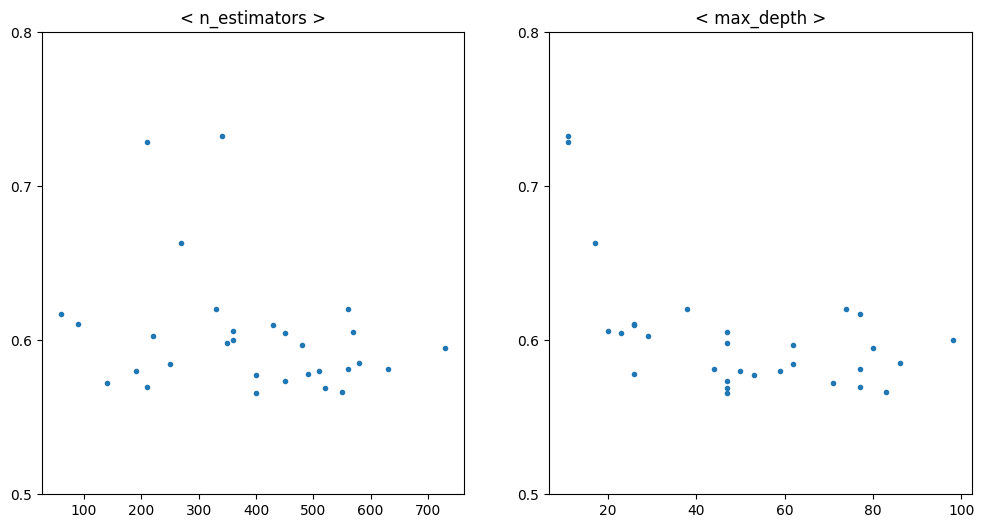

In [ ]:
# n_estimators, max_depth에 대해 성능 변화를 시각화합니다

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].scatter(random_result["param_n_estimators"], -random_result["mean_test_score"], marker='.')
ax[0].set_title("< n_estimators >")
ax[0].set_yticks([0.5, 0.6, 0.7, 0.8])
ax[1].scatter(random_result["param_max_depth"], -random_result["mean_test_score"], marker='.')
ax[1].set_title("< max_depth >")
ax[1].set_yticks([0.5, 0.6, 0.7, 0.8])

plt.show()

`n_estimators` 파라미터는 변화에 따른 성능 변화가 뚜렷하지 않지만,<br>
`max_depth` 파라미터는 20 이하와 20 이상의 성능 변화가 뚜렷하게 나타납니다.

#### **2. 학습 시간 변화 시각화**

하이퍼파라미터 튜닝에서 또 하나 중요한 요소는 소요 시간입니다.<br>

이번에는 학습 시간의 변화를 시각화 해보도록 할게요!<br>
`max_features`와 `n_estimators` 파라미터에 대해 소요 시간 변화를 시각화 해보겠습니다.

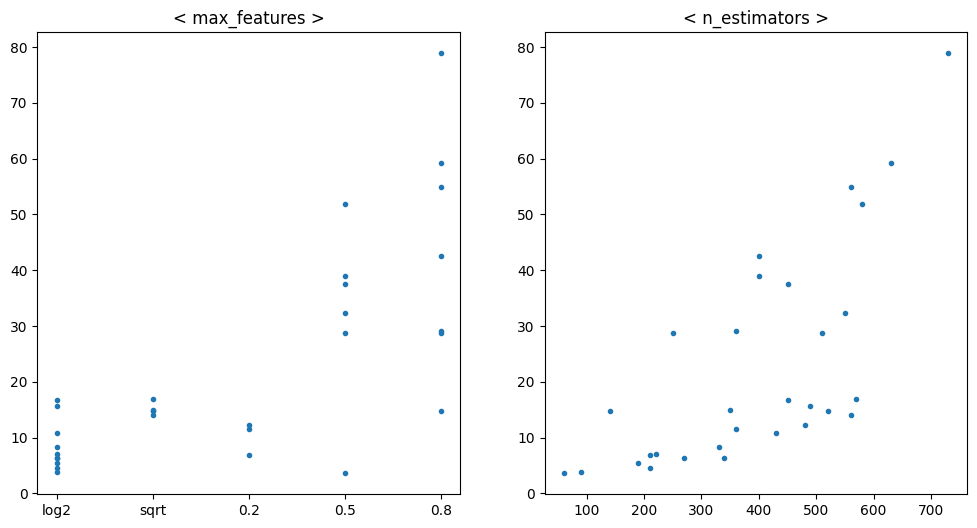

In [ ]:
# max_features, n_estimators에 대해 소요 시간의 변화를 시각화합니다

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

max_features = random_result["param_max_features"].map({"log2": 0,
                                                        "sqrt": 1,
                                                        0.2: 2,
                                                        0.5: 3,
                                                        0.8: 4})

ax[0].scatter(max_features, random_result["mean_fit_time"], marker='.')
ax[0].set_title("< max_features >")
ax[0].set_xticks([0, 1, 2, 3, 4])
ax[0].set_xticklabels(["log2", "sqrt", "0.2", "0.5", "0.8"])
ax[1].scatter(random_result["param_n_estimators"], random_result["mean_fit_time"], marker='.')
ax[1].set_title("< n_estimators >")

plt.show()

두 파라미터 모두 변화에 따라 학습 시간에 큰 영향을 미치는 것을 알 수 있습니다.

최고의 파라미터 조합과 최고의 점수도 각각 출력해볼게요!

In [ ]:
# 최고의 파라미터 조합과 최고의 점수를 출력합니다
random_best_params = random_rf.best_params_
random_best_score = random_rf.best_score_

print(f"Best params: {random_best_params}")
print(f"Best score: {round(-random_best_score, 4)}")

Best params: {'n_estimators': 400, 'min_samples_split': 4, 'max_features': 0.8, 'max_depth': 47, 'criterion': 'entropy'}
Best score: 0.5658


다시 한 번 학습시켜 최종적으로 비교해보도록 하겠습니다.

In [ ]:
rf_tune2 = random_rf.best_estimator_

rf_tune2.fit(X_train, y_train)
y_prob2 = rf_tune2.predict_proba(X_valid)

log_loss_random = log_loss(y_valid, y_prob2)

In [ ]:
# 파라미터 튜닝 전과 비교합니다

print(f"Base model: {round(log_loss_2, 4)}")
print(f"Random Search: {round(log_loss_random, 4)}")

Base model: 0.4966
Random Search: 0.4867


### **3. HyperOpt**

GridSearch와 RandomSearch 이 외에도 자주 사용되는 파이썬 패키지들이 있습니다.<br>
대표적인 패키지로 HyperOpt, Optuna, Tune 등의 패키지가 있습니다.<br>
저희는 그 중 하나인 **HyperOpt**를 사용해서 하이퍼파라미터 튜닝을 해보도록 하겠습니다!

💡 **HyperOpt**<br>
HyperOpt는 베이지안 최적화 기법에 기반한 하이퍼파라미터 튜닝 패키지입니다.<br>
모든 가능한 조합을 시도하지 않고, 조금 더 빠르게 하이퍼파라미터 공간을 탐색하는 방법을 제공합니다.<br>

HyperOpt는 TPE(Tree-structured Parzen Estimator) 알고리즘을 사용해서 더 빠르게 최적화합니다.

HyperOpt가 앞의 두 방법과 다른 점은 <font color=blue>**이전의 튜닝 결과를 활용**</font>한다는 점입니다.<br>
앞의 두 방법은 주어진 파라미터 셋에서 단순 조합으로 결과를 산출했지만,<br>
HyperOpt는 TPE 알고리즘으로 이전의 튜닝 결과에서 더 나아질 수 있도록 새로운<br>
파라미터 조합을 만들어내어 탐색합니다.

HyperOpt를 사용하기 위해서 먼저 패키지를 설치해주겠습니다!

In [ ]:
# HyeprOpt 패키지를 설치합니다
!pip install hyperopt

In [ ]:
from hyperopt import tpe, hp, Trials
from hyperopt.fmin import fmin

💡 **주요 함수 및 파라미터 설명**

HyperOpt의 주요 함수 및 파라미터는 다음과 같습니다!<br>

1. `fmin()`<br>
HyperOpt의 핵심 함수로, 목적 함수의 최솟값을 찾는 데 도와줍니다.<br>
가장 작은 손실을 낸 하이퍼파라미터를 반환합니다.<br>
주요 파라미터는 다음과 같습니다.

  1. `fn`: 최적화시킬 모델입니다. 반드시 하이퍼파라미터 샘플을 제공받아야 합니다.

  2. `space`: 샘플링 대상이 되는 하이퍼파라미터 공간입니다.

  3. `algo`: 최적화 알고리즘입니다. 이번 프로젝트에서는 tpe.suggest 알고리즘을 사용하였습니다.

  4. `max_evals`: 샘플링할 횟수입니다.

2. `Trials()`: 최적화 기록을 추적할 클래스 객체입니다.

3. `hp`: 하이퍼파라미터 생성을 도와주는 모듈입니다.

4. `tpe`: tpe.suggest 알고리즘을 포함하고 있는 모듈입니다.

앞에서의 하이퍼파라미터 튜닝 결과에 따라 `n_estimators`는 최댓값을 700으로 설정해주도록 하겠습니다.<br>
또한, `max_depth`는 최솟값 20, 최댓값 100으로 설정해주겠습니다!

충분한 하이퍼파라미터 공간 탐색을 위해, `max_evals=100`으로 설정해주었습니다.

In [ ]:
def objective(params):
    est = int(params['n_estimators'])
    md = int(params['max_depth'])
    msl = int(params['min_samples_leaf'])
    mss = int(params['min_samples_split'])
    model = RandomForestClassifier(n_estimators=est, max_depth=md, min_samples_leaf=msl, min_samples_split=mss)
    model.fit(X_train, y_train)
    pred = model.predict_proba(X_valid)
    score = log_loss(y_valid, pred)
    return score

def optimize(trial):
    params={'n_estimators': hp.uniform('n_estimators', 50, 700),
           'max_depth': hp.uniform('max_depth', 20, 100),
           'min_samples_leaf': hp.uniform('min_samples_leaf', 1, 5),
           'min_samples_split': hp.uniform('min_samples_split', 2, 6)}
    best=fmin(fn=objective, space=params, algo=tpe.suggest, trials=trial, max_evals=100)
    return best

trial=Trials()
best=optimize(trial)

100%|██████████| 100/100 [33:01<00:00, 19.81s/trial, best loss: 0.49315847304659594]


하이퍼파라미터 튜닝이 끝났네요! 가장 좋은 파라미터 조합을 보도록 하겠습니다.

In [ ]:
print(f"best: {best}")

best: {'max_depth': 97.98531996843613, 'min_samples_leaf': 1.2716488525554541, 'min_samples_split': 2.9542265929855605, 'n_estimators': 478.46936194582247}


정수형 하이퍼파라미터들이 모두 실수형으로 출력되었습니다.<br>
정수로 바꿔주고, 최종 학습 시켜보도록 하겠습니다!

In [ ]:
max_depth = round(best["max_depth"])
min_samples_leaf = round(best["min_samples_leaf"])
min_samples_split = round(best["min_samples_split"])
n_estimators = round(best["n_estimators"])

rf_tune3 = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                  min_samples_leaf=min_samples_leaf,
                                  min_samples_split=min_samples_split, random_state=42)
rf_tune3.fit(X_train, y_train)
y_prob3 = rf_tune3.predict_proba(X_valid)

log_loss_hyopt = log_loss(y_valid, y_prob3)

In [ ]:
# 파라미터 튜닝 전과 비교합니다

print(f"Base model: {round(log_loss_2, 4)}")
print(f"HyperOpt: {round(log_loss_hyopt, 4)}")

Base model: 0.4966
HyperOpt: 0.5017


이렇게 하이퍼파라미터 튜닝을 마치도록 하겠습니다!

## **Step 3. 예측 결과 저장 및 제출**

**Random Search**의 결과가 제일 좋았기 때문에, 해당 값으로 하이퍼파라미터를 세팅해주도록 하겠습니다.

In [ ]:
model = RandomForestClassifier(n_estimators=400, min_samples_split=4,
                              max_features=0.8, max_depth=47, criterion="entropy",
                              random_state=42)

model.fit(X_train, y_train)
y_prob = model.predict_proba(X_valid)

log_loss_final = log_loss(y_valid, y_prob)
print(f"log_loss: {round(log_loss_final, 4)}")

log_loss: 0.4867


In [ ]:
y_pred = model.predict_proba(test)

In [ ]:
# 예측 결과를 제출 파일에 저장합니다

submission.iloc[:, 1:] = y_pred
submission

,index,0,1,2
0,26457,0.048583,0.040375,0.911042
1,26458,0.276458,0.184417,0.539125
2,26459,0.052708,0.127083,0.820208
3,26460,0.326375,0.228292,0.445333
4,26461,0.109750,0.352958,0.537292
...,...,...,...,...
9995,36452,0.188333,0.253833,0.557833
9996,36453,0.648699,0.079051,0.272250
9997,36454,0.010542,0.008750,0.980708
9998,36455,0.053750,0.334536,0.611714


In [ ]:
# submit.csv라는 파일로 저장합니다

submission.to_csv("submit.csv", index=False)